In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
#Loading the dataset
credit_card_data = pd.read_csv('/content/creditcard.csv')

In [ ]:
credit_card_data.shape

(284807, 31)

In [ ]:
#Exploring the Dataset-First 5 columns
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#Exploring the Dataset-Last 5 columns
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [ ]:
#Dataset Information-We can see that no null values are there
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
credit_card_data.isnull().sum()
#There are no missing values in this dataset

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
#Distribution of legit and fraudulent transactions
#0->Legit transactions and 1->fraudulent transactions
credit_card_data['Class'].value_counts()

,count
Class,
0,284315
1,492


The dataset is highly unbalanced
0-> Normal transaction
1->Fraudulent transaction

In [ ]:
#Separating the Data for Analysis
legit= credit_card_data[credit_card_data.Class==0]
fraud=credit_card_data[credit_card_data.Class==1]

In [ ]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


Statistical measures of the Data

In [ ]:
legit.Amount.describe()
#We can see that the mean amount of legit transactions is 88$ nearly

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [ ]:
fraud.Amount.describe()
#We can see that the mean amount of fraudulent transactions is 122$, which is much higher than mean transaction amount of legit transactions

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [ ]:
#Comparing the values of both legit and fraud transactions
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,-0.006576,0.010832,0.000189,0.012064,0.000161,0.007164,0.011535,0.003887,-0.001178,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Since the Data is quite unbalanced -90% of the data lies in legit transaction and only 10% for fraud transaction, we are using Undersampling

In [ ]:
#Building a Sample Dataset containing similar distribution of normal and fraudulent transactions
#Taking randomly 492 samples from Legit transaction to create a balanced dataset

legit_sample = legit.sample(n=492)

Concatening both Legit and Fraud dataframes row wise

In [ ]:
New_dataset = pd.concat([legit_sample,fraud],axis=0)

In [ ]:
New_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
52457,45461.0,-1.259648,-0.189711,0.582742,-1.724311,-0.991640,-1.243282,-1.918122,0.119576,-3.114640,-1.026211,0.234441,-3.999959,0.271681,-3.169654,0.039151,-2.487190,-4.167016,-1.318090,-0.016760,0.187287,0.134863,-0.268528,-0.301073,-0.205946,0.556283,-0.253942,0.253858,0.020416,10.00,0
168434,119223.0,2.067612,0.186982,-1.652488,0.438475,0.397454,-0.931461,0.212815,-0.263964,0.431681,-0.389136,-0.413457,0.374628,0.411074,-0.910769,0.157688,0.269286,0.490101,-0.386014,0.011518,-0.135483,-0.353523,-0.895925,0.347972,0.648645,-0.259597,0.164020,-0.060219,-0.028586,1.98,0
184187,126131.0,1.426608,-1.456952,-0.520949,0.732923,-1.016658,0.144509,-0.443701,0.121890,2.055426,-0.530452,-1.468291,0.201951,-1.078642,-0.197248,-0.261848,-0.262406,-0.109308,-0.043190,0.253105,0.263458,-0.064759,-0.537323,0.106573,0.684527,-0.371369,-0.921656,0.017377,0.025163,283.00,0
239246,150019.0,-1.756647,1.409935,-2.037640,-1.869212,2.512001,4.034718,-1.194529,-2.217086,-0.203082,-1.239921,-0.610436,0.628690,-0.647703,1.059845,-0.444891,-0.149122,-0.205318,-0.603595,-0.552867,0.063632,-0.539132,-0.221076,0.403208,0.640643,-0.682853,-0.753276,-0.301468,0.203168,25.00,0
176922,122969.0,1.889977,-0.300459,-0.239864,1.207237,-0.364374,0.408343,-0.736617,0.257210,0.867758,0.314065,0.620468,0.932544,-0.188724,0.045087,-0.331246,0.418688,-0.812865,0.713032,-0.396067,-0.224688,0.257203,0.892585,0.148326,0.694048,-0.082047,-0.580590,0.057255,-0.033086,12.00,0


In [ ]:
New_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,-5.587794,2.115795,-5.417424,-1.235123,-6.665177,0.401701,-2.897825,-4.570529,-1.315147,0.391167,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,-3.232153,2.858466,-3.096915,-0.792532,-5.210141,-0.613803,-2.155297,-3.267116,-0.688505,0.737657,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,-3.463891,1.794969,-2.775022,-0.418950,-4.057162,-0.712616,-1.603015,-5.035326,-0.507000,0.266272,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,-5.245984,1.933520,-5.030465,-1.127455,-6.416628,0.141237,-2.549498,-4.614717,-1.478138,-0.035480,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,-0.888722,0.491140,0.728903,0.380428,-1.948883,-0.832498,0.519436,0.903562,1.197315,0.593509,-0.017652,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [ ]:
New_dataset['Class'].value_counts()
#Verifying the size of our New dataset- its evenly balanced now

,count
Class,
0,492
1,492


In [ ]:
New_dataset.groupby('Class').mean()
# Mean remains similar even now for fraud transactions after undersampling as well.

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,93684.981707,-0.098884,-0.062040,-0.002548,0.082756,-0.035680,0.065347,-0.044650,-0.065065,-0.056784,-0.004791,0.020100,-0.031714,0.063045,0.052884,0.011292,0.057434,0.053153,-0.023717,0.000668,-0.020072,0.007546,0.034771,0.025747,-0.004313,0.023819,0.024184,-0.023127,-0.013804,99.520305
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,3.800173,-6.259393,-0.109334,-6.971723,-0.092929,-4.139946,-6.665836,-2.246308,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Splitting the Data into features and targets

In [ ]:
X= New_dataset.drop(columns = 'Class',axis =1)
Y= New_dataset['Class']

In [ ]:
X.head()
#Column Class is dropped from X now

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
52457,45461.0,-1.259648,-0.189711,0.582742,-1.724311,-0.991640,-1.243282,-1.918122,0.119576,-3.114640,-1.026211,0.234441,-3.999959,0.271681,-3.169654,0.039151,-2.487190,-4.167016,-1.318090,-0.016760,0.187287,0.134863,-0.268528,-0.301073,-0.205946,0.556283,-0.253942,0.253858,0.020416,10.00
168434,119223.0,2.067612,0.186982,-1.652488,0.438475,0.397454,-0.931461,0.212815,-0.263964,0.431681,-0.389136,-0.413457,0.374628,0.411074,-0.910769,0.157688,0.269286,0.490101,-0.386014,0.011518,-0.135483,-0.353523,-0.895925,0.347972,0.648645,-0.259597,0.164020,-0.060219,-0.028586,1.98
184187,126131.0,1.426608,-1.456952,-0.520949,0.732923,-1.016658,0.144509,-0.443701,0.121890,2.055426,-0.530452,-1.468291,0.201951,-1.078642,-0.197248,-0.261848,-0.262406,-0.109308,-0.043190,0.253105,0.263458,-0.064759,-0.537323,0.106573,0.684527,-0.371369,-0.921656,0.017377,0.025163,283.00
239246,150019.0,-1.756647,1.409935,-2.037640,-1.869212,2.512001,4.034718,-1.194529,-2.217086,-0.203082,-1.239921,-0.610436,0.628690,-0.647703,1.059845,-0.444891,-0.149122,-0.205318,-0.603595,-0.552867,0.063632,-0.539132,-0.221076,0.403208,0.640643,-0.682853,-0.753276,-0.301468,0.203168,25.00
176922,122969.0,1.889977,-0.300459,-0.239864,1.207237,-0.364374,0.408343,-0.736617,0.257210,0.867758,0.314065,0.620468,0.932544,-0.188724,0.045087,-0.331246,0.418688,-0.812865,0.713032,-0.396067,-0.224688,0.257203,0.892585,0.148326,0.694048,-0.082047,-0.580590,0.057255,-0.033086,12.00


In [ ]:
print(Y)
#Y has Class with both legit and fraud values

52457     0
168434    0
184187    0
239246    0
176922    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


Splitting the data into Training and Testing data

In [ ]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size = 0.2,stratify=Y,random_state=2)

In [ ]:
#Checking the shape and distribution of X training and testing data
print(X.shape,X_train.shape,X_test.shape)

(984, 30) (787, 30) (197, 30)


In [ ]:
#Checking the shape and distribution of Y training and testing data
print(Y.shape,Y_train.shape,Y_test.shape)

(984,) (787,) (197,)


Model Training

To tackle the convergence issue , we are scaling the dataset

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
#Training on scaled Data

model=LogisticRegression(max_iter=1000,solver='liblinear',class_weight='balanced')
model.fit(X_train_scaled,Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

Model Evaluation

In [ ]:
#Accuracy on training data
X_train_prediction= model.predict(X_train_scaled)
training_data_accuracy= accuracy_score(X_train_prediction,Y_train)

In [ ]:
print('Accuracy on training data:', training_data_accuracy)

Accuracy on training data: 0.951715374841169


In [ ]:
#Checking Accuracy on test data
X_test_prediction = model.predict(X_test_scaled)
test_data_accuracy=accuracy_score(X_test_prediction,Y_test)

In [ ]:
print('Accuracy on test data:', test_data_accuracy)

Accuracy on test data: 0.9441624365482234


Predicting Values for Test set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

Y_pred=model.predict(X_test_scaled)

In [ ]:
print(confusion_matrix(Y_test,Y_pred)) #Prediction vs Reality

[[98  1]
 [10 88]]


In [ ]:
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95        99
           1       0.99      0.90      0.94        98

    accuracy                           0.94       197
   macro avg       0.95      0.94      0.94       197
weighted avg       0.95      0.94      0.94       197



Visualization

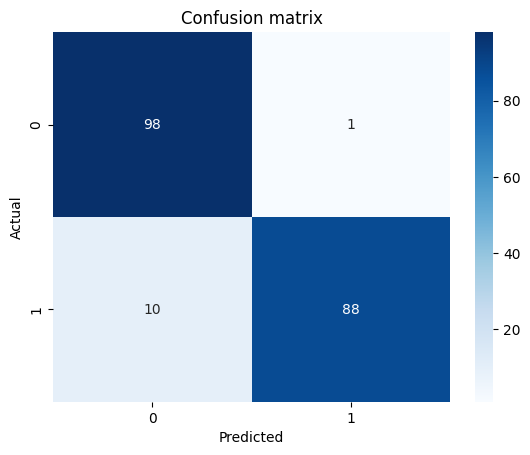

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(Y_test,Y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()